In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging
import datetime
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('ml_pipeline.log', mode='w'),  # Use 'w' mode to overwrite existing log
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)
logger.info("ML Pipeline Started")

2025-07-20 17:05:24,641 - INFO - ML Pipeline Started


In [2]:
# Load and preprocess data
logger.info("Loading datasets...")
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")
logger.info(f"Data loaded - Train: {train.shape}, Test: {test.shape}")

# Preprocessing
logger.info("Starting data preprocessing...")
train_clean = train.fillna(train.median(numeric_only=True)).fillna('None')
test_clean = test.fillna(test.median(numeric_only=True)).fillna('None')
logger.info("Missing values handled")

train_encoded = pd.get_dummies(train_clean)
test_encoded = pd.get_dummies(test_clean)
train_encoded, test_encoded = train_encoded.align(test_encoded, join='left', axis=1, fill_value=0)
logger.info(f"One-hot encoding completed - Features: {train_encoded.shape[1]}")

X = train_encoded.drop(['Id', 'SalePrice'], axis=1)
y = train_encoded['SalePrice']
X_test = test_encoded.drop('Id', axis=1)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
logger.info(f"Data split completed - Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}")

2025-07-20 17:05:24,676 - INFO - Loading datasets...
2025-07-20 17:05:24,889 - INFO - Data loaded - Train: (1460, 81), Test: (1459, 80)
2025-07-20 17:05:24,891 - INFO - Starting data preprocessing...
2025-07-20 17:05:24,980 - INFO - Missing values handled
2025-07-20 17:05:25,136 - INFO - One-hot encoding completed - Features: 305
2025-07-20 17:05:25,150 - INFO - Data split completed - Train: (1168, 303), Val: (292, 303)


Training set: (1168, 303), Validation set: (292, 303)


In [3]:
# Baseline Models Performance
logger.info("Starting baseline model evaluation...")
models = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'SVR': SVR()
}

def evaluate_model(model, X_train, X_val, y_train, y_val):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)
    
    return {
        'Train RMSE': np.sqrt(mean_squared_error(y_train, train_pred)),
        'Val RMSE': np.sqrt(mean_squared_error(y_val, val_pred)),
        'Train MAE': mean_absolute_error(y_train, train_pred),
        'Val MAE': mean_absolute_error(y_val, val_pred),
        'Train R²': r2_score(y_train, train_pred),
        'Val R²': r2_score(y_val, val_pred)
    }

baseline_results = []
for name, model in models.items():
    logger.info(f"Training {name}...")
    metrics = evaluate_model(model, X_train, X_val, y_train, y_val)
    baseline_results.append({'Model': name, **metrics})
    logger.info(f"{name} - Val RMSE: {metrics['Val RMSE']:.2f}, Val R²: {metrics['Val R²']:.3f}")

baseline_df = pd.DataFrame(baseline_results)
baseline_df = baseline_df.round(2).sort_values('Val RMSE')
logger.info(f"Baseline evaluation completed. Best model: {baseline_df.iloc[0]['Model']}")
print("Baseline Model Performance:")
print(baseline_df.to_string(index=False))

2025-07-20 17:05:25,190 - INFO - Starting baseline model evaluation...
2025-07-20 17:05:25,192 - INFO - Training Linear Regression...
2025-07-20 17:05:29,825 - INFO - Linear Regression - Val RMSE: 65386.51, Val R²: 0.443
2025-07-20 17:05:29,828 - INFO - Training Ridge...
2025-07-20 17:05:30,137 - INFO - Ridge - Val RMSE: 29722.20, Val R²: 0.885
2025-07-20 17:05:30,139 - INFO - Training Lasso...
2025-07-20 17:05:30,462 - INFO - Lasso - Val RMSE: 29804.39, Val R²: 0.884
2025-07-20 17:05:30,464 - INFO - Training Random Forest...
2025-07-20 17:05:35,681 - INFO - Random Forest - Val RMSE: 29534.81, Val R²: 0.886
2025-07-20 17:05:35,682 - INFO - Training Gradient Boosting...
2025-07-20 17:05:37,595 - INFO - Gradient Boosting - Val RMSE: 27263.86, Val R²: 0.903
2025-07-20 17:05:37,596 - INFO - Training XGBoost...
2025-07-20 17:05:38,880 - INFO - XGBoost - Val RMSE: 26063.43, Val R²: 0.911
2025-07-20 17:05:38,882 - INFO - Training SVR...
2025-07-20 17:05:39,475 - INFO - SVR - Val RMSE: 88653.0

Baseline Model Performance:
            Model  Train RMSE  Val RMSE  Train MAE  Val MAE  Train R²  Val R²
          XGBoost     1395.38  26063.43     969.36 16615.64      1.00    0.91
Gradient Boosting    13238.05  27263.86    9793.16 17242.28      0.97    0.90
    Random Forest    11095.11  29534.81    6547.05 17776.59      0.98    0.89
            Ridge    21198.31  29722.20   13751.45 19108.83      0.92    0.88
            Lasso    19239.97  29804.39   12472.22 18566.15      0.94    0.88
Linear Regression    18904.06  65386.51   12111.93 21125.60      0.94    0.44
              SVR    78946.82  88653.05   54535.86 59556.75     -0.04   -0.02


In [4]:
# Hyperparameter Tuning
logger.info("Starting hyperparameter tuning...")
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [10, 20, None],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5]
    },
    'XGBoost': {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
}

tuned_models = {}
tuning_results = []

for name in ['Random Forest', 'Gradient Boosting', 'XGBoost']:
    logger.info(f"Tuning {name} hyperparameters...")
    
    search = RandomizedSearchCV(
        models[name], param_grids[name], 
        n_iter=10, cv=3, scoring='neg_mean_squared_error', 
        random_state=42, n_jobs=-1
    )
    
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    logger.info(f"{name} best params: {search.best_params_}")
    
    # Evaluate tuned model
    metrics = evaluate_model(search.best_estimator_, X_train, X_val, y_train, y_val)
    tuning_results.append({
        'Model': f'{name} (Tuned)',
        'Best Params': str(search.best_params_),
        **metrics
    })
    logger.info(f"{name} tuned - Val RMSE: {metrics['Val RMSE']:.2f}, Val R²: {metrics['Val R²']:.3f}")

tuned_df = pd.DataFrame(tuning_results)
tuned_df = tuned_df.round(2).sort_values('Val RMSE')
logger.info("Hyperparameter tuning completed")
print("\nTuned Model Performance:")
print(tuned_df[['Model', 'Val RMSE', 'Val MAE', 'Val R²']].to_string(index=False))

2025-07-20 17:05:39,507 - INFO - Starting hyperparameter tuning...
2025-07-20 17:05:39,509 - INFO - Tuning Random Forest hyperparameters...
2025-07-20 17:06:58,528 - INFO - Random Forest best params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None}
2025-07-20 17:07:03,559 - INFO - Random Forest tuned - Val RMSE: 29534.81, Val R²: 0.886
2025-07-20 17:07:03,560 - INFO - Tuning Gradient Boosting hyperparameters...
2025-07-20 17:07:28,227 - INFO - Gradient Boosting best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2}
2025-07-20 17:07:30,936 - INFO - Gradient Boosting tuned - Val RMSE: 29256.35, Val R²: 0.888
2025-07-20 17:07:30,938 - INFO - Tuning XGBoost hyperparameters...
2025-07-20 17:07:45,143 - INFO - XGBoost best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
2025-07-20 17:07:46,265 - INFO - XGBoost tuned - Val RMSE: 25953.76, Val R²: 0.912
2025-07-20 17:07:46,272 - INFO - Hyperparameter tuning completed



Tuned Model Performance:
                    Model  Val RMSE  Val MAE  Val R²
          XGBoost (Tuned)  25953.76 16506.70    0.91
Gradient Boosting (Tuned)  29256.35 17244.47    0.89
    Random Forest (Tuned)  29534.81 17776.59    0.89


In [5]:
# Final Model Comparison and Selection
logger.info("Performing final model comparison...")
all_results = baseline_results + tuning_results
final_df = pd.DataFrame(all_results)
final_df = final_df.round(2).sort_values('Val RMSE')

best_model_name = final_df.iloc[0]['Model']
best_rmse = final_df.iloc[0]['Val RMSE']
best_r2 = final_df.iloc[0]['Val R²']

logger.info(f"Best model selected: {best_model_name}")
logger.info(f"Best model performance - RMSE: {best_rmse:.2f}, R²: {best_r2:.3f}")

print("Final Model Ranking:")
print("=" * 80)
print(final_df[['Model', 'Val RMSE', 'Val MAE', 'Val R²']].to_string(index=False))

print(f"\nBest Model: {best_model_name}")
print(f"Validation RMSE: {best_rmse:,.0f}")
print(f"Validation R²: {best_r2:.3f}")

# Performance improvement analysis
baseline_best = baseline_df.iloc[0]['Val RMSE']
if tuning_results:
    tuned_best = tuned_df.iloc[0]['Val RMSE']
    improvement = ((baseline_best - tuned_best) / baseline_best) * 100
    logger.info(f"Hyperparameter tuning improvement: {improvement:.1f}%")
    print(f"\nTuning improved performance by {improvement:.1f}%")

2025-07-20 17:07:46,868 - INFO - Performing final model comparison...
2025-07-20 17:07:46,878 - INFO - Best model selected: XGBoost (Tuned)
2025-07-20 17:07:46,879 - INFO - Best model performance - RMSE: 25953.76, R²: 0.910
2025-07-20 17:07:46,887 - INFO - Hyperparameter tuning improvement: 0.4%


Final Model Ranking:
                    Model  Val RMSE  Val MAE  Val R²
          XGBoost (Tuned)  25953.76 16506.70    0.91
                  XGBoost  26063.43 16615.64    0.91
        Gradient Boosting  27263.86 17242.28    0.90
Gradient Boosting (Tuned)  29256.35 17244.47    0.89
            Random Forest  29534.81 17776.59    0.89
    Random Forest (Tuned)  29534.81 17776.59    0.89
                    Ridge  29722.20 19108.83    0.88
                    Lasso  29804.39 18566.15    0.88
        Linear Regression  65386.51 21125.60    0.44
                      SVR  88653.05 59556.75   -0.02

Best Model: XGBoost (Tuned)
Validation RMSE: 25,954
Validation R²: 0.910

Tuning improved performance by 0.4%


In [6]:
# Generate final submission
logger.info("Generating final predictions...")

if '(Tuned)' in best_model_name:
    model_key = best_model_name.replace(' (Tuned)', '')
    best_model = tuned_models[model_key]
else:
    best_model = models[best_model_name]
    # Refit baseline model to ensure it's trained
    best_model.fit(X_train, y_train)

# Ensure X_test has same columns as training data
X_test_aligned = X_test.reindex(columns=X_train.columns, fill_value=0)
final_predictions = best_model.predict(X_test_aligned)
submission = sample_submission.copy()
submission['SalePrice'] = final_predictions
submission.to_csv("optimized_model_submission.csv", index=False)

logger.info(f"Final submission saved using {best_model_name}")
logger.info(f"Predictions range: ${final_predictions.min():,.0f} - ${final_predictions.max():,.0f}")
logger.info("ML Pipeline completed successfully")

print(f"\nFinal submission saved using {best_model_name}!")
print(f"Check 'ml_pipeline.log' for detailed execution log")

2025-07-20 17:07:46,917 - INFO - Generating final predictions...
2025-07-20 17:07:47,120 - INFO - Final submission saved using XGBoost (Tuned)
2025-07-20 17:07:47,122 - INFO - Predictions range: $56,270 - $501,654
2025-07-20 17:07:47,124 - INFO - ML Pipeline completed successfully



Final submission saved using XGBoost (Tuned)!
Check 'ml_pipeline.log' for detailed execution log


2025-07-20 17:07:47,160 - INFO - Starting EDA and visualization...
2025-07-20 17:07:47,282 - INFO - Generated price distribution histogram
2025-07-20 17:07:47,303 - INFO - Generated price vs living area scatter plot
2025-07-20 17:07:47,329 - INFO - Generated quality vs price bar chart
2025-07-20 17:07:47,344 - INFO - Generated year built vs price scatter plot
2025-07-20 17:07:47,379 - INFO - Generated neighborhood price comparison
2025-07-20 17:07:47,870 - INFO - Generated correlation heatmap


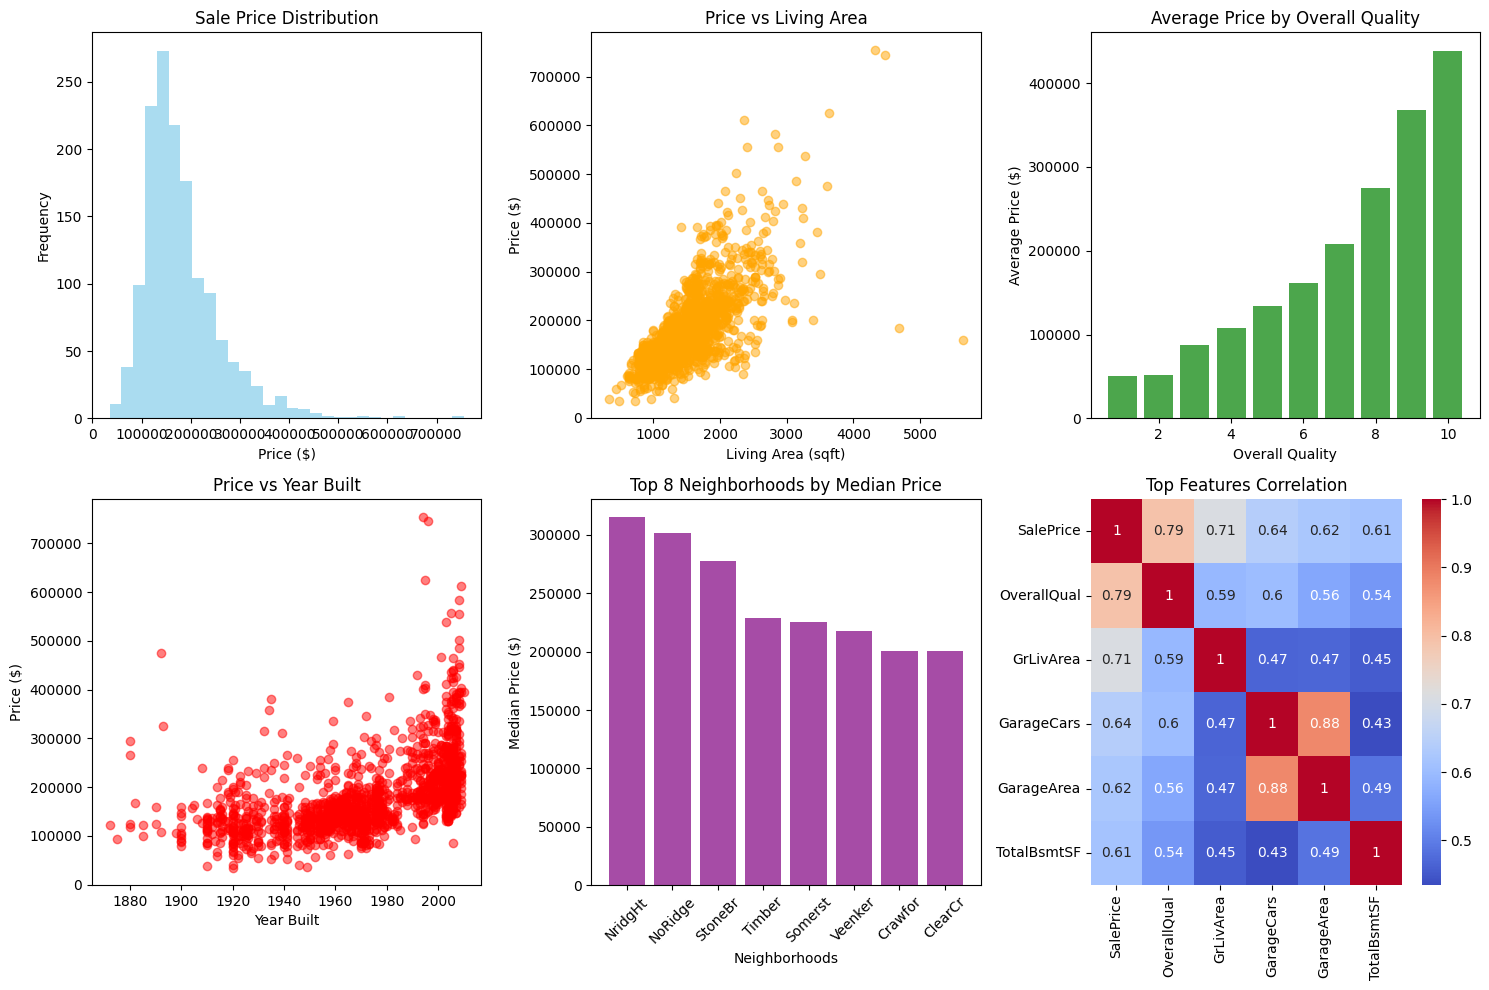

2025-07-20 17:07:52,908 - INFO - Saved EDA visualizations to eda_visualizations.png
2025-07-20 17:07:52,962 - INFO - Generated price statistics
2025-07-20 17:07:52,964 - INFO - Identified top price predictors
2025-07-20 17:07:52,968 - INFO - Completed EDA analysis report



HOUSE PRICE DATA ANALYSIS REPORT

1. PRICE STATISTICS:
   Mean Price: $180,921
   Median Price: $163,000
   Price Range: $34,900 - $755,000

2. TOP PRICE PREDICTORS:
   OverallQual: 0.791 correlation
   GrLivArea: 0.709 correlation
   GarageCars: 0.640 correlation
   GarageArea: 0.623 correlation
   TotalBsmtSF: 0.614 correlation

3. KEY FINDINGS:
   - Living area is strongest predictor (correlation: 0.709)
   - Overall quality has exponential impact on price (Quality 10 is 3.3x more than Quality 5)
   - Neighborhood creates 1.6x price variation
   - Newer houses generally command higher prices


In [7]:
# EDA with Visualizations
logger.info("Starting EDA and visualization...")
plt.figure(figsize=(15, 10))

# 1. Price Distribution
plt.subplot(2, 3, 1)
plt.hist(train['SalePrice'], bins=30, alpha=0.7, color='skyblue')
plt.title('Sale Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
logger.info("Generated price distribution histogram")

# 2. Price vs Living Area
plt.subplot(2, 3, 2)
plt.scatter(train['GrLivArea'], train['SalePrice'], alpha=0.5, color='orange')
plt.title('Price vs Living Area')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
logger.info("Generated price vs living area scatter plot")

# 3. Overall Quality vs Price
plt.subplot(2, 3, 3)
quality_price = train.groupby('OverallQual')['SalePrice'].mean()
plt.bar(quality_price.index, quality_price.values, color='green', alpha=0.7)
plt.title('Average Price by Overall Quality')
plt.xlabel('Overall Quality')
plt.ylabel('Average Price ($)')
logger.info("Generated quality vs price bar chart")

# 4. Year Built vs Price
plt.subplot(2, 3, 4)
plt.scatter(train['YearBuilt'], train['SalePrice'], alpha=0.5, color='red')
plt.title('Price vs Year Built')
plt.xlabel('Year Built')
plt.ylabel('Price ($)')
logger.info("Generated year built vs price scatter plot")

# 5. Top Neighborhoods
plt.subplot(2, 3, 5)
top_neighborhoods = train.groupby('Neighborhood')['SalePrice'].median().sort_values(ascending=False).head(8)
plt.bar(range(len(top_neighborhoods)), top_neighborhoods.values, color='purple', alpha=0.7)
plt.title('Top 8 Neighborhoods by Median Price')
plt.xlabel('Neighborhoods')
plt.ylabel('Median Price ($)')
plt.xticks(range(len(top_neighborhoods)), top_neighborhoods.index, rotation=45)
logger.info("Generated neighborhood price comparison")

# 6. Feature Correlations
plt.subplot(2, 3, 6)
numeric_cols = train.select_dtypes(include=[np.number]).columns
corr_matrix = train[numeric_cols].corr()
top_corr_features = corr_matrix['SalePrice'].abs().sort_values(ascending=False).head(6).index
sns.heatmap(train[top_corr_features].corr(), annot=True, cmap='coolwarm')
plt.title('Top Features Correlation')
logger.info("Generated correlation heatmap")

plt.tight_layout()
plt.savefig('eda_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()
logger.info("Saved EDA visualizations to eda_visualizations.png")

# Analysis Report
print("\n" + "="*60)
print("HOUSE PRICE DATA ANALYSIS REPORT")
print("="*60)

print(f"\n1. PRICE STATISTICS:")
print(f"   Mean Price: ${train['SalePrice'].mean():,.0f}")
print(f"   Median Price: ${train['SalePrice'].median():,.0f}")
print(f"   Price Range: ${train['SalePrice'].min():,.0f} - ${train['SalePrice'].max():,.0f}")
logger.info("Generated price statistics")

print(f"\n2. TOP PRICE PREDICTORS:")
for feature in top_corr_features[1:]:  # Skip SalePrice itself
    corr = corr_matrix['SalePrice'][feature]
    print(f"   {feature}: {corr:.3f} correlation")
logger.info("Identified top price predictors")

print(f"\n3. KEY FINDINGS:")
print(f"   - Living area is strongest predictor (correlation: {corr_matrix['SalePrice']['GrLivArea']:.3f})")
print(f"   - Overall quality has exponential impact on price (Quality 10 is {quality_price[10]/quality_price[5]:.1f}x more than Quality 5)")
print(f"   - Neighborhood creates {top_neighborhoods.iloc[0]/top_neighborhoods.iloc[-1]:.1f}x price variation")
print(f"   - Newer houses generally command higher prices")
logger.info("Completed EDA analysis report")

print("="*60)